# Analyse Exploratoire des Données (EDA)

## Chargement des données et exploration initiale

In [3]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("gestionlogistique").getOrCreate()
df = spark.read.option("header", "true").csv("data/output_tmp/part-00000-039c67c4-4607-444e-be84-ab46ccdf438b-c000.csv")

df.show()
df.printSchema()

+-------------+------------------------+-----------------------------+-----------------+------------------+------------------+---------------+-------------------+------------------------+-------------------+----------------+----------------------+--------+----------------+----------------+--------------+--------------------+---------------+--------------+------------------+
|Order Country|Days for shipping (real)|Days for shipment (scheduled)|Benefit per order|Sales per customer|Late_delivery_risk|Department Name|Order Item Quantity|Order Item Product Price|Order Item Discount|Order Item Total|Order Profit Per Order|    Type| Delivery Status|   Category Name|Customer State|         Order State|   Order Region| Shipping Mode|          distance|
+-------------+------------------------+-----------------------------+-----------------+------------------+------------------+---------------+-------------------+------------------------+-------------------+----------------+----------------------

25/11/19 00:25:24 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


## Conversion des colonnes numériques en type double

In [4]:
from pyspark.sql import functions as f

numbers_columns = [
    'Benefit per order',
    'Sales per customer',
    'Order Item Quantity',
    'Order Item Product Price',
    'Order Item Discount',
    'Order Item Total',
    'Order Profit Per Order',
    'distance',
    'Late_delivery_risk'
]

for c in numbers_columns:
    df = df.withColumn(c, f.col(c).cast("double"))


## Analyse des valeurs manquantes

In [5]:
for i in df.columns:
    null_count = df.filter(df[i].isNull()).count()
    print(f"{i}: {null_count} valeurs nulles")

Order Country: 0 valeurs nulles
Days for shipping (real): 0 valeurs nulles
Days for shipment (scheduled): 0 valeurs nulles
Benefit per order: 0 valeurs nulles
Sales per customer: 0 valeurs nulles
Late_delivery_risk: 0 valeurs nulles
Department Name: 0 valeurs nulles
Order Item Quantity: 0 valeurs nulles
Order Item Product Price: 0 valeurs nulles
Order Item Discount: 0 valeurs nulles
Order Item Total: 0 valeurs nulles
Order Profit Per Order: 0 valeurs nulles
Type: 0 valeurs nulles
Delivery Status: 0 valeurs nulles
Category Name: 0 valeurs nulles
Customer State: 0 valeurs nulles
Order State: 0 valeurs nulles
Order Region: 0 valeurs nulles
Shipping Mode: 0 valeurs nulles
distance: 0 valeurs nulles


## Visualisation de la distribution des variables numériques

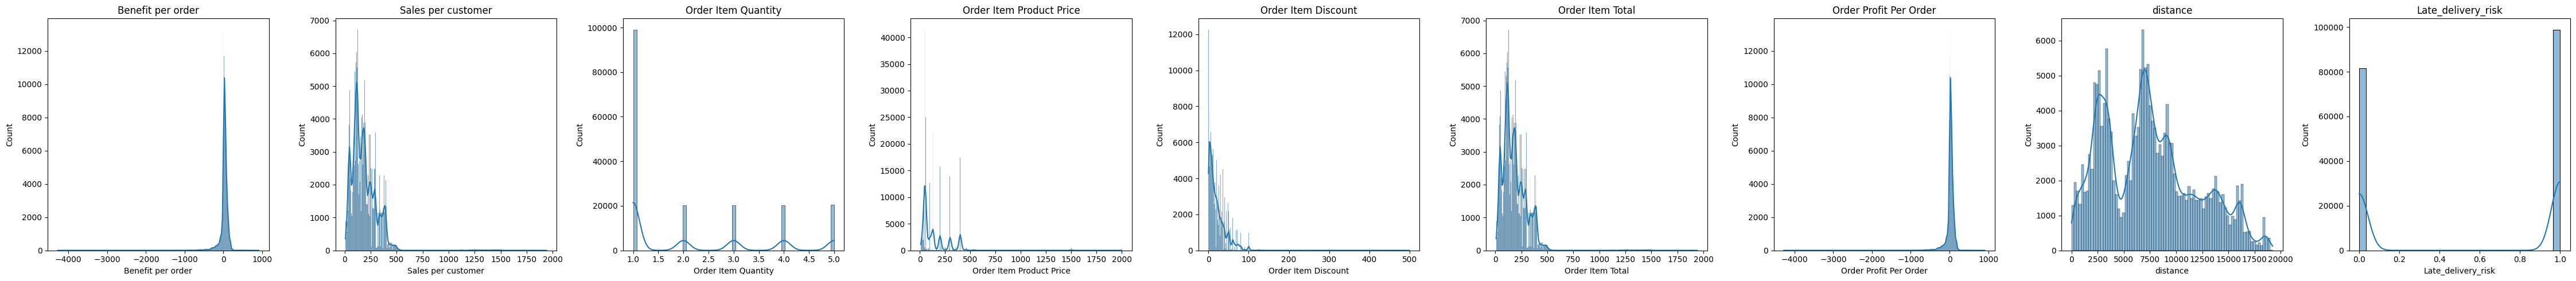

In [6]:
import matplotlib.pyplot as plt 
import seaborn as sbn 

plt.figure(figsize=(5*len(numbers_columns), 5))

for i, col in enumerate(numbers_columns):
    plt.subplot(1, len(numbers_columns), i+1)
    sbn.histplot(df.select(col).toPandas()[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

## Matrice de corrélation entre les variables numériques

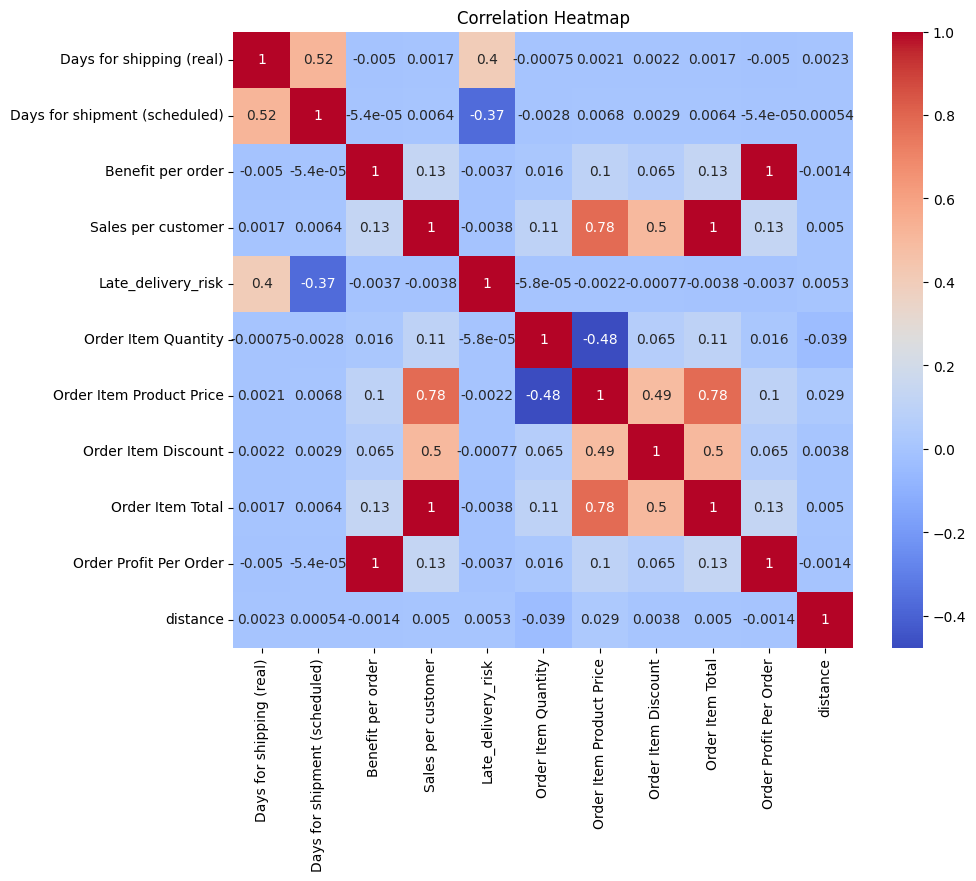

In [15]:
import matplotlib.pyplot as plt 
import seaborn as sbn 

df_numeric = df.select(numbers_columns).toPandas()

plt.figure(figsize=(10, 8))
sbn.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Conversion en DataFrame Pandas pour l'analyse des outliers

In [7]:
df_numeric = df.select(numbers_columns).toPandas()

## Détection des valeurs aberrantes (outliers) avec des boxplots

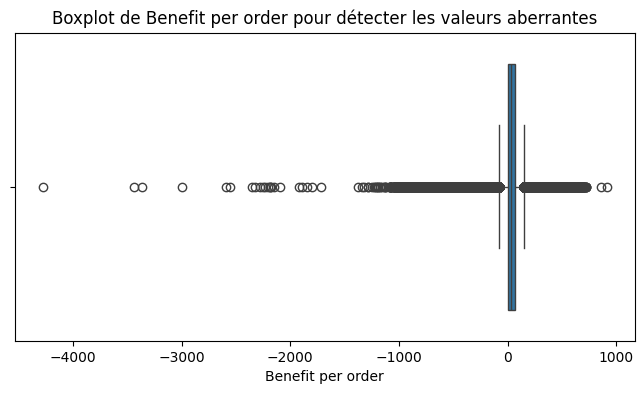

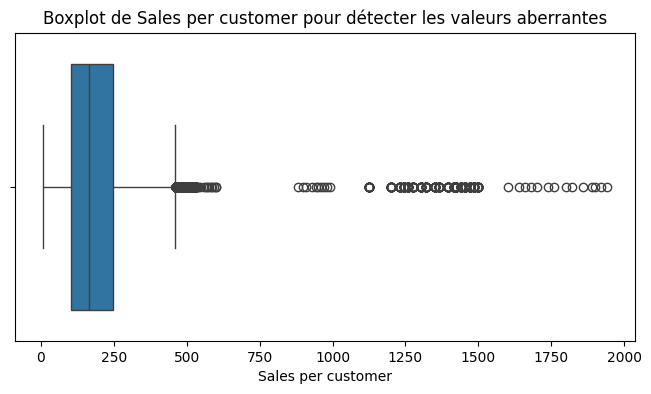

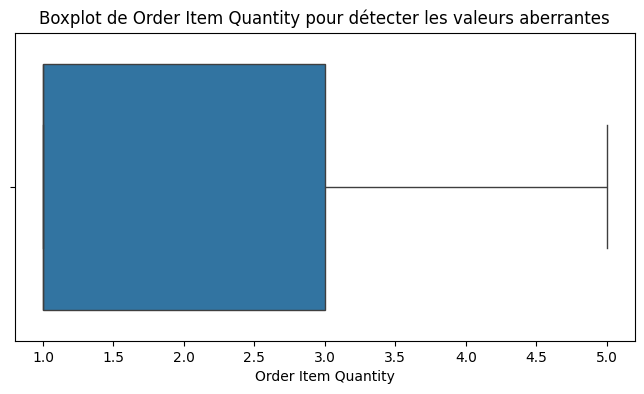

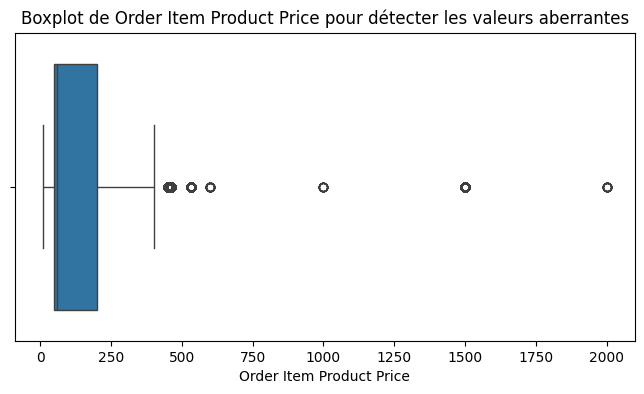

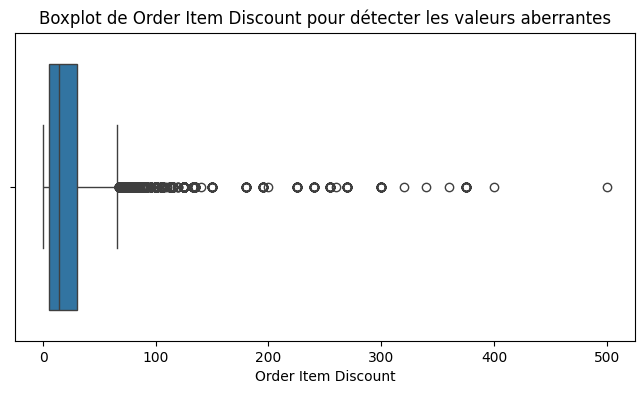

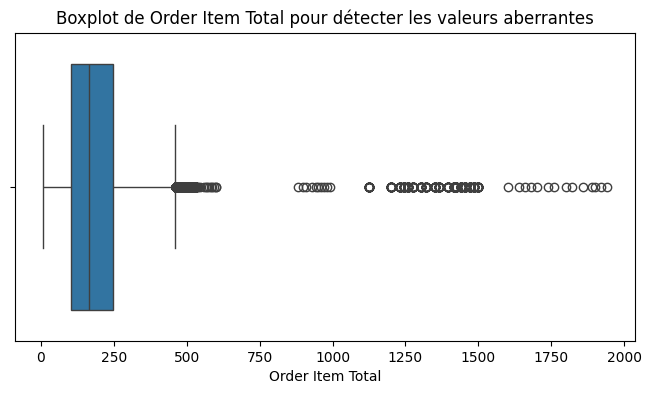

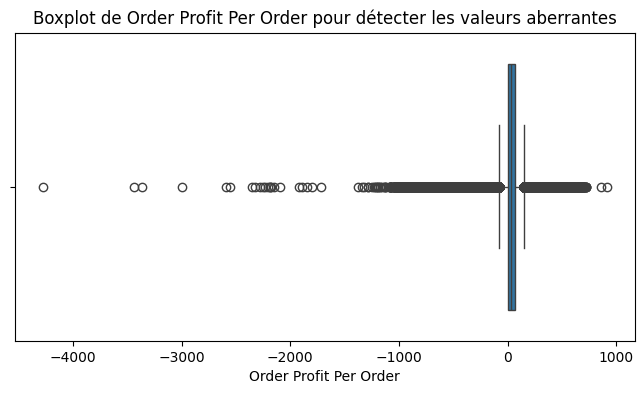

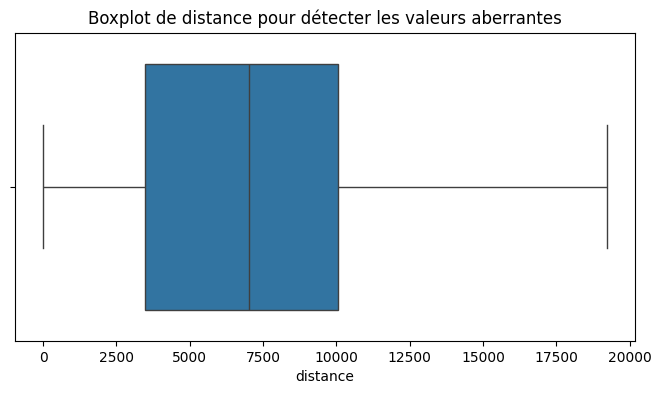

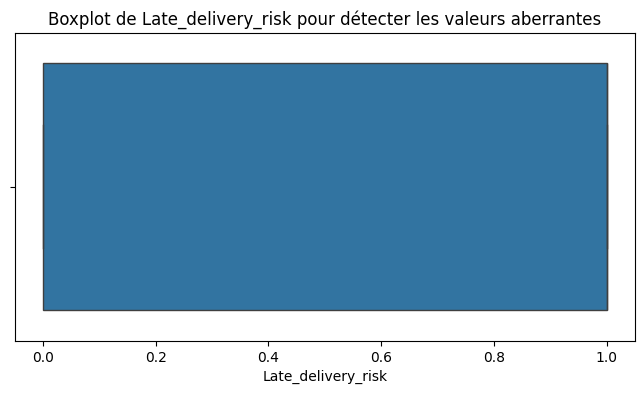

In [11]:
for col in numbers_columns:
    plt.figure(figsize=(8,4))
    sbn.boxplot(x=df_numeric[col])
    plt.title(f"Boxplot de {col} pour détecter les valeurs aberrantes")
    plt.show()

## Distribution de la variable cible (Late_delivery_risk)

   Late_delivery_risk  count
0                 0.0  81509
1                 1.0  98887


/tmp/ipykernel_4189/2638210716.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sbn.barplot(x="Late_delivery_risk", y="count", data=count_df, palette="viridis")


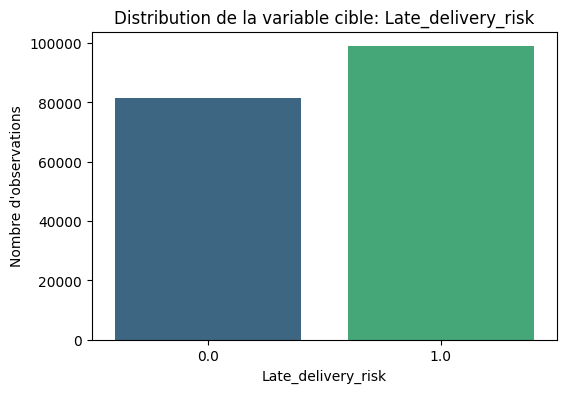

25/11/19 07:54:48 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 16305194 ms exceeds timeout 120000 ms
25/11/19 07:54:48 WARN SparkContext: Killing executors is not supported by current scheduler.
25/11/19 07:54:57 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint

In [ ]:
from pyspark.sql import functions as F

count_df = df.groupBy("Late_delivery_risk").agg(F.count("*").alias("count")).toPandas()
print(count_df)
plt.figure(figsize=(6,4))
sbn.barplot(x="Late_delivery_risk", y="count", data=count_df, palette="viridis")
plt.title("Distribution de la variable cible: Late_delivery_risk")
plt.xlabel("Late_delivery_risk")
plt.ylabel("Nombre d'observations")
plt.show()